In [ ]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('ggplot')

In [2]:
#create mall customer dataset
np.random.seed(42)

n = 500

customer_id = np.arange(1, n+1)

age = np.random.randint(18, 70, n)

annual_income = np.random.randint(15, 150, n)

spending_score = np.random.randint(1, 100, n)

gender = np.random.choice(['Male', 'Female'], n)

df = pd.DataFrame({
    'CustomerID': customer_id,
    'Gender': gender,
    'Age': age,
    'Annual Income (k$)': annual_income,
    'Spending Score (1-100)': spending_score
})

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,56,30,72
1,2,Female,69,83,92
2,3,Male,46,36,31
3,4,Male,32,107,9
4,5,Male,60,90,51


In [3]:
#dataset overview
print("Dataset Shape:", df.shape)

display(df.head())

df.info()

display(df.describe())

Dataset Shape: (500, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,56,30,72
1,2,Female,69,83,92
2,3,Male,46,36,31
3,4,Male,32,107,9
4,5,Male,60,90,51


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              500 non-null    int64
 1   Gender                  500 non-null    str  
 2   Age                     500 non-null    int64
 3   Annual Income (k$)      500 non-null    int64
 4   Spending Score (1-100)  500 non-null    int64
dtypes: int64(4), str(1)
memory usage: 19.7 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,500.000000,500.000000,500.00000,500.000000
mean,250.500000,44.220000,81.28400,49.928000
std,144.481833,15.036082,39.28075,28.984254
min,1.000000,18.000000,15.00000,1.000000
25%,125.750000,32.000000,48.00000,25.000000
50%,250.500000,45.000000,82.00000,49.000000
75%,375.250000,57.000000,115.00000,74.000000
max,500.000000,69.000000,149.00000,99.000000


In [4]:
#missing values 
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

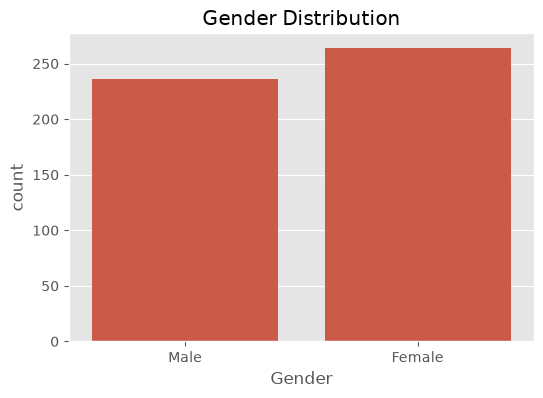

In [5]:
#gender distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df
)

plt.title("Gender Distribution")

plt.show()

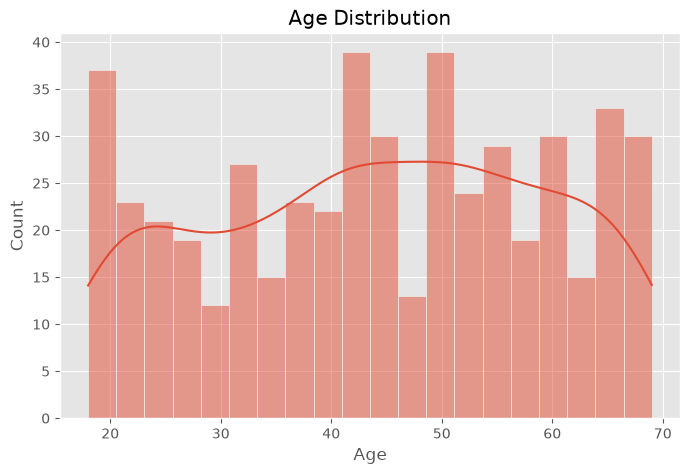

In [6]:
#age distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

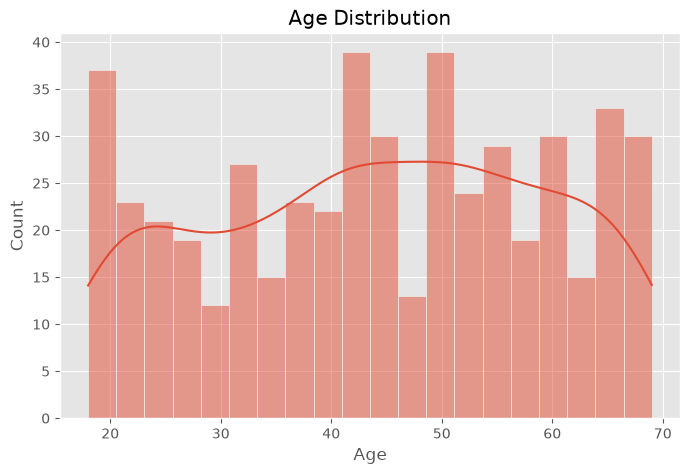

In [7]:
#income distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

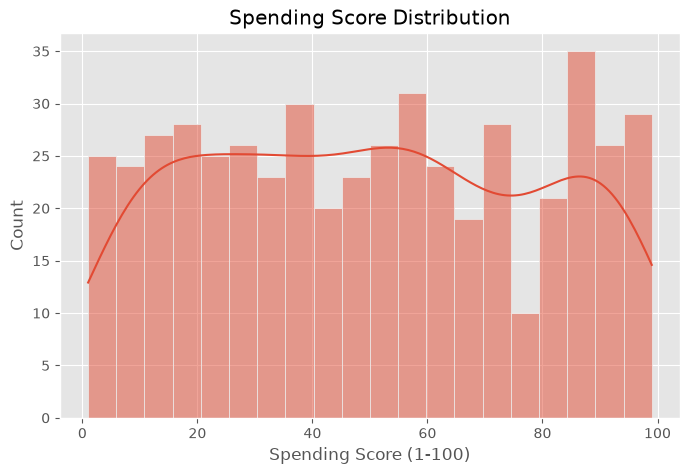

In [8]:
#spending score distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")

plt.show()

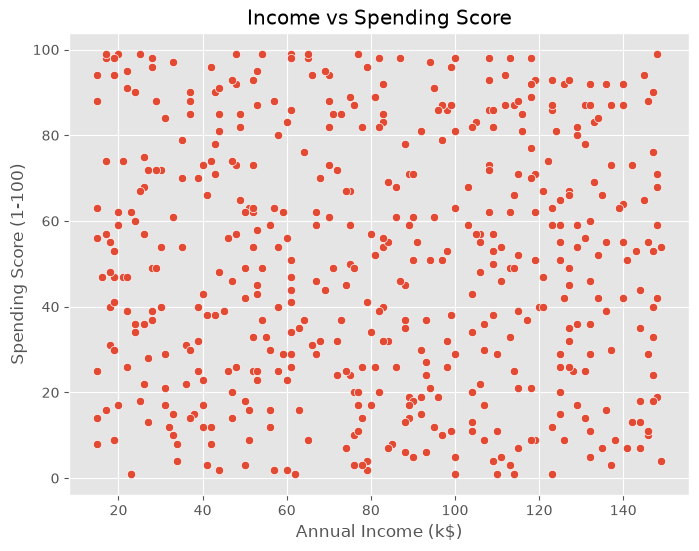

In [9]:
#scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")

plt.show()

In [10]:
#feature selection
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [11]:
#standardization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

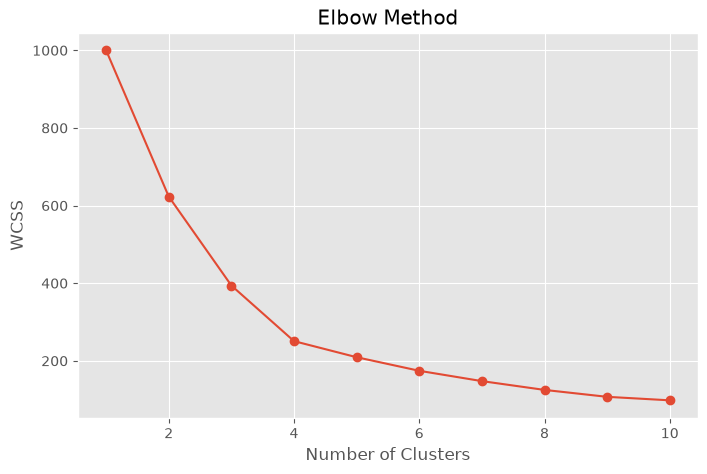

In [12]:
#elbow method
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [13]:
#train k means
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,56,30,72,0
1,2,Female,69,83,92,3
2,3,Male,46,36,31,1
3,4,Male,32,107,9,4
4,5,Male,60,90,51,2


In [14]:
#clustercounts
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    centers,
    columns=[
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

centers_df

,Annual Income (k$),Spending Score (1-100)
0,44.587156,77.431193
1,43.172414,28.043103
2,115.820000,50.170000
3,112.575000,84.875000
4,107.221053,15.410526


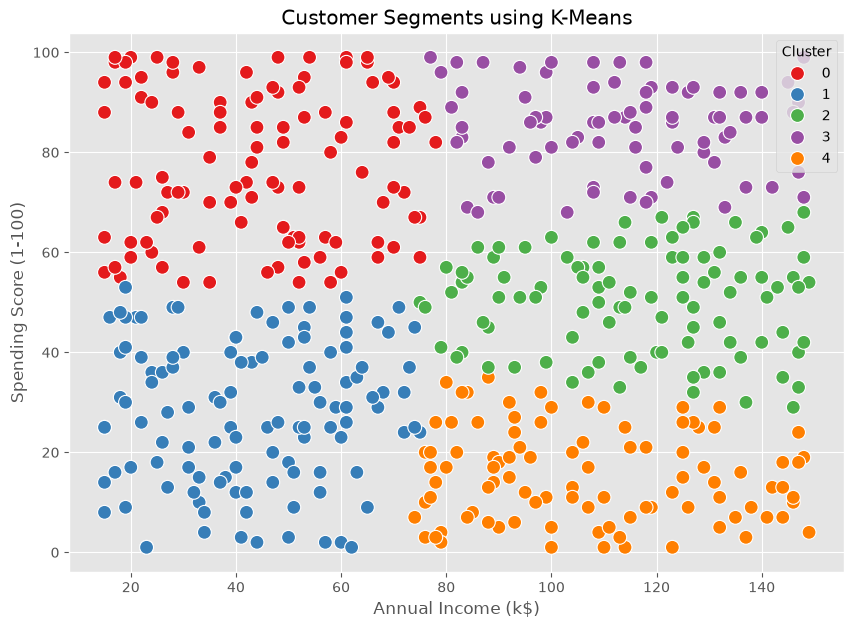

In [15]:
#customer segments vizualization
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segments using K-Means")

plt.show()

In [16]:
#cluster centres
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    centers,
    columns=[
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

centers_df

,Annual Income (k$),Spending Score (1-100)
0,44.587156,77.431193
1,43.172414,28.043103
2,115.820000,50.170000
3,112.575000,84.875000
4,107.221053,15.410526


In [17]:
#business interpretation
cluster_summary = df.groupby('Cluster')[[
    'Annual Income (k$)',
    'Spending Score (1-100)',
    'Age'
]].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,44.587156,77.431193,43.862385
1,43.172414,28.043103,44.387931
2,115.820000,50.170000,46.440000
3,112.575000,84.875000,41.187500
4,107.221053,15.410526,44.642105


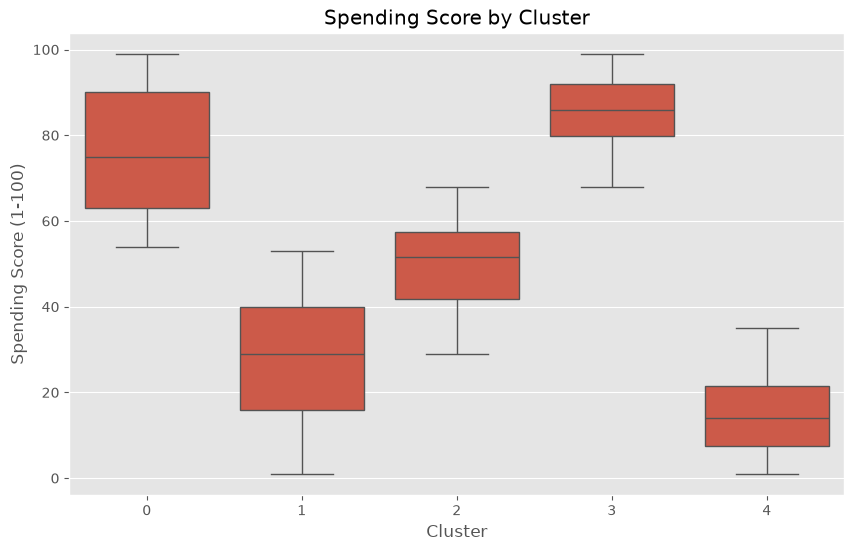

In [18]:
#boxplot analysis
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Spending Score by Cluster")

plt.show()

In [19]:
#save result dataset
df.to_csv(
    "Customer_Segments.csv",
    index=False
)

print("Customer_Segments.csv saved successfully")

Customer_Segments.csv saved successfully
